In [1]:
# Data handling
import pandas as pd
import numpy as np

# Preprocessing
#from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Model
from sklearn.ensemble import RandomForestRegressor


#from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#import seaborn as sns
import matplotlib.pyplot as plt

# Optional: for handling imbalanced data (later step)
#from imblearn.over_sampling import SMOTE

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import root_mean_squared_error

import joblib

import streamlit as st


In [2]:
# Replace 'your_file.csv' with your actual file name or path
df = pd.read_csv('updated_dataset.csv')

# Show the first few rows
print(df.head())


   User_ID  Age Gender  Social_Media_Hours  Exercise_Hours  Sleep_Hours  \
0        1   16      F            9.654486               2            5   
1        2   17      M            9.158143               0            9   
2        3   15      M            5.028755               1            5   
3        4   17      F            7.951103               1            5   
4        5   17      F            1.357459               1            6   

   Screen_Time_Hours  Survey_Stress_Score  Wearable_Stress_Score  \
0                  8                    3               0.288962   
1                  5                    5               0.409446   
2                  9                    2               0.423837   
3                 10                    5               0.666021   
4                 11                    5               0.928060   

  Support_System  ... Peer_Pressure  Mood_Rating  Self_Esteem_Score  \
0       Moderate  ...             2            2               2.57  

In [3]:
df['Screen_Time_Hours'] = df['Screen_Time_Hours'].round().astype(int)
df['Sleep_Hours'] = df['Sleep_Hours'].round().astype(int)
df['Exercise_Hours'] = df['Exercise_Hours'].round().astype(int)
df['Social_Media_Hours'] = df['Social_Media_Hours'].round().astype(int)
print(df.head())


   User_ID  Age Gender  Social_Media_Hours  Exercise_Hours  Sleep_Hours  \
0        1   16      F                  10               2            5   
1        2   17      M                   9               0            9   
2        3   15      M                   5               1            5   
3        4   17      F                   8               1            5   
4        5   17      F                   1               1            6   

   Screen_Time_Hours  Survey_Stress_Score  Wearable_Stress_Score  \
0                  8                    3               0.288962   
1                  5                    5               0.409446   
2                  9                    2               0.423837   
3                 10                    5               0.666021   
4                 11                    5               0.928060   

  Support_System  ... Peer_Pressure  Mood_Rating  Self_Esteem_Score  \
0       Moderate  ...             2            2               2.57  

In [4]:
print("\nMissing values in each column:")
print(df.isnull().sum())



Missing values in each column:
User_ID                  0
Age                      0
Gender                   0
Social_Media_Hours       0
Exercise_Hours           0
Sleep_Hours              0
Screen_Time_Hours        0
Survey_Stress_Score      0
Wearable_Stress_Score    0
Support_System           0
Academic_Performance     0
 Social_Media_Hours      0
Parental_Pressure        0
Peer_Pressure            0
Mood_Rating              0
Self_Esteem_Score        0
Relationship_Issues      0
Time_Management          0
Home_Environment         0
Sleep_Quality            0
Financial_Stress         0
Diet_Quality             0
Anxiety_Symptoms         0
dtype: int64


In [5]:


# Create label encoders for each categorical column
#le_gender = LabelEncoder()
#le_support = LabelEncoder()
#le_performance = LabelEncoder()

# Apply encoders
#df['Gender'] = le_gender.fit_transform(df['Gender'])  # F = 0, M = 1
#df['Support_System'] = le_support.fit_transform(df['Support_System'])  # Low=1, Moderate=2, High=0 (may vary)
#df['Academic_Performance'] = le_performance.fit_transform(df['Academic_Performance'])  # Order will be auto-assigned
df['Gender'] = df['Gender'].map({'F': 0, 'M': 1})  # F = 0, M = 1
df['Support_System'] = df['Support_System'].map({'Low': 0, 'Moderate': 1, 'High': 2})
df['Academic_Performance'] = df['Academic_Performance'].map({
    'Poor': 0,
    'Average': 1,
    'Good': 2,
    'Excellent': 3
})
# Check the result
print(df.head())

# Optional: Show class mappings
#print("\nLabel Mapping:")
#print("Gender:", list(le_gender.classes_))
#print("Support_System:", list(le_support.classes_))
#print("Academic_Performance:", list(le_performance.classes_))


   User_ID  Age  Gender  Social_Media_Hours  Exercise_Hours  Sleep_Hours  \
0        1   16       0                  10               2            5   
1        2   17       1                   9               0            9   
2        3   15       1                   5               1            5   
3        4   17       0                   8               1            5   
4        5   17       0                   1               1            6   

   Screen_Time_Hours  Survey_Stress_Score  Wearable_Stress_Score  \
0                  8                    3               0.288962   
1                  5                    5               0.409446   
2                  9                    2               0.423837   
3                 10                    5               0.666021   
4                 11                    5               0.928060   

   Support_System  ...  Peer_Pressure  Mood_Rating  Self_Esteem_Score  \
0               1  ...              2            2           

In [6]:
# Add derived features
df['Stress_Gap'] = df['Survey_Stress_Score'] - df['Wearable_Stress_Score']
#df['Lifestyle_Score'] = df['Exercise_Hours'] + df['Sleep_Hours'] - df['Social_Media_Hours']


MAE: 0.0016817908657800243
MSE: 0.00015191231046382563
RMSE: 0.012325271212586992
R² Score: 0.9981983212697539


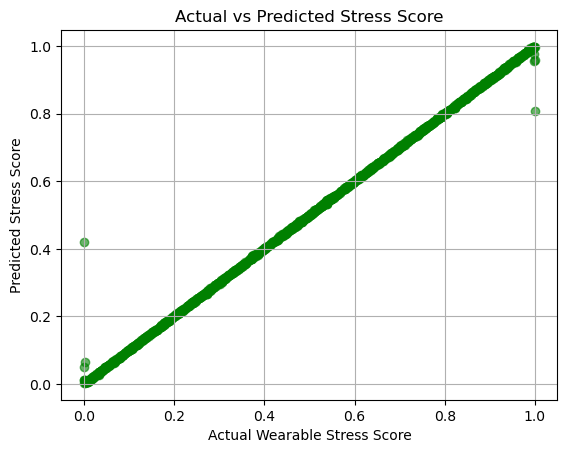

In [7]:


#  Features and Target (excluding User_ID and Performance label)
X = df.drop(['User_ID', 'Wearable_Stress_Score'], axis=1)
y = df['Wearable_Stress_Score']


# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Retrain Random Forest
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)


# Predict
y_pred = rf_regressor.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)
print("R² Score:", r2_score(y_test, y_pred))


# train-test split on resampled data
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.xlabel("Actual Wearable Stress Score")
plt.ylabel("Predicted Stress Score")
plt.title("Actual vs Predicted Stress Score")
plt.grid(True)
plt.show()


In [8]:
# Save model
joblib.dump(rf_regressor, 'wearable_stress_model.pkl')

['wearable_stress_model.pkl']

In [ ]:

new_data = pd.DataFrame([{
    'Age': 16,
    'Gender': 0,  # Female
    'Social_Media_Hours': 4.5,
    'Exercise_Hours': 1.2,
    'Sleep_Hours': 7.0,
    'Screen_Time_Hours': 6.5,
    'Survey_Stress_Score': 4,
    'Support_System': 1,  # e.g., Moderate
    'Academic_Performance': 2,  # e.g., Good
    'Stress_Gap': 4 - 0.4,
    'Lifestyle_Score': 1.2 + 7.0 - 4.5
}])

predicted_stress = rf_regressor.predict(new_data)
print("Predicted Wearable Stress Score:", predicted_stress[0])


In [ ]:
pip install streamlit


In [ ]:

# Load your trained model
model = joblib.load('wearable_stress_model.pkl')

st.title("Predict Your Wearable Stress Score")

# Input fields
age = st.number_input("Age", min_value=10, max_value=100, value=16)
gender = st.selectbox("Gender", ['Female', 'Male'])  # Will encode: Female=0, Male=1
social_media = st.slider("Social Media Hours", 0.0, 15.0, 4.5)
exercise = st.slider("Exercise Hours", 0.0, 5.0, 1.2)
sleep = st.slider("Sleep Hours", 0.0, 12.0, 7.0)
screen_time = st.slider("Screen Time Hours", 0.0, 15.0, 6.5)
survey_stress = st.slider("Survey Stress Score", 1, 5, 4)
support_system = st.selectbox("Support System", ['Low', 'Moderate', 'High'])
academic_performance = st.selectbox("Academic Performance", ['Average', 'Excellent', 'Good', 'Poor'])

# Encode categorical inputs to match training
gender_enc = 0 if gender == 'Female' else 1
support_enc = {'High': 0, 'Low': 1, 'Moderate': 2}[support_system]
performance_enc = {'Average': 0, 'Excellent': 1, 'Good': 2, 'Poor': 3}[academic_performance]

# Derived features
stress_gap = survey_stress - 0.4  # dummy expected wearable stress
lifestyle_score = exercise + sleep - social_media

# Build input DataFrame
input_data = pd.DataFrame([{
    'Age': age,
    'Gender': gender_enc,
    'Social_Media_Hours': social_media,
    'Exercise_Hours': exercise,
    'Sleep_Hours': sleep,
    'Screen_Time_Hours': screen_time,
    'Survey_Stress_Score': survey_stress,
    'Support_System': support_enc,
    'Academic_Performance': performance_enc,
    'Stress_Gap': stress_gap,
    'Lifestyle_Score': lifestyle_score
}])

# Predict
if st.button("Predict Stress Score"):
    prediction = model.predict(input_data)[0]
    st.success(f"Predicted Wearable Stress Score: **{prediction:.4f}**")

    # Optional interpretation
    if prediction < 0.33:
        st.info("Likely Low Stress")
    elif prediction < 0.66:
        st.warning("Likely Moderate Stress")
    else:
        st.error("Likely High Stress")
